In [1]:
!pip install thinkdsp-kim
import thinkdsp

# Упражнение 1.2

In [14]:
from thinkdsp import read_wave, Signal
wave = read_wave('847071__billyguiro__alternative-intro-logo-guitar-sad-155bpm.wav')


In [36]:
wave.make_audio()

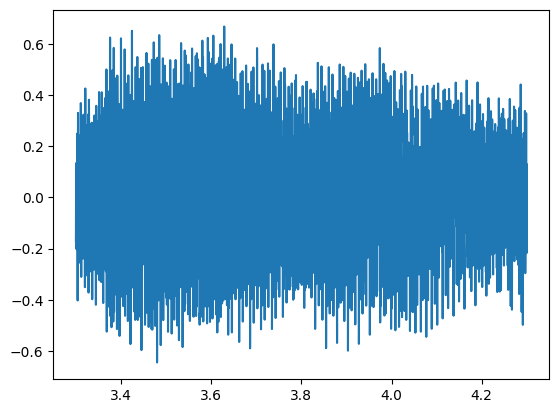

In [65]:
segment = wave.segment(start = 3.3, duration=1)
segment.plot()

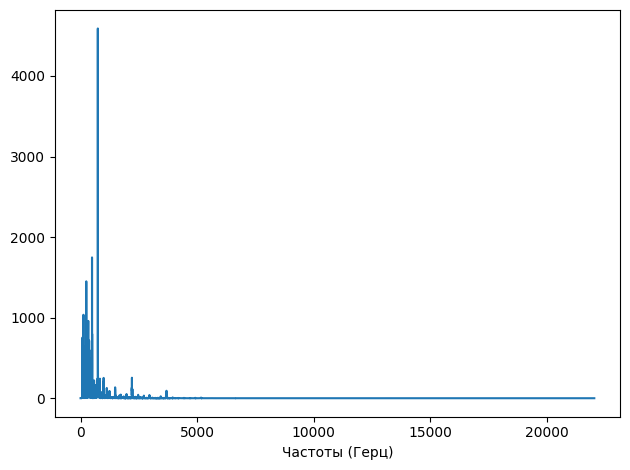

In [66]:
#from matplotlib import plot
from thinkdsp import decorate

spectrum = segment.make_spectrum()
spectrum.plot()
decorate(xlabel = "Частоты (Герц)")

Чем больше низкочастотных звуков, мягкхи и приглушенных, тем более богатый на разные низкочастотные гармоники спектр
Чем более богатый звук, больше высокочастотных, звонких звуков, тем более богатый на разные высокочастотные гармоники спектр

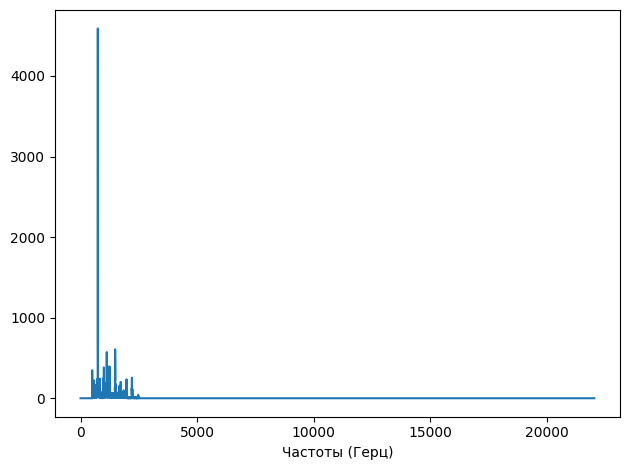

In [76]:
spectrum.high_pass(cutoff=500, factor=0)
spectrum.low_pass(cutoff=2500, factor=0)
spectrum.band_stop(low_cutoff=1000, high_cutoff=2000,factor=3)

spectrum.plot()
decorate(xlabel = "Частоты (Герц)")

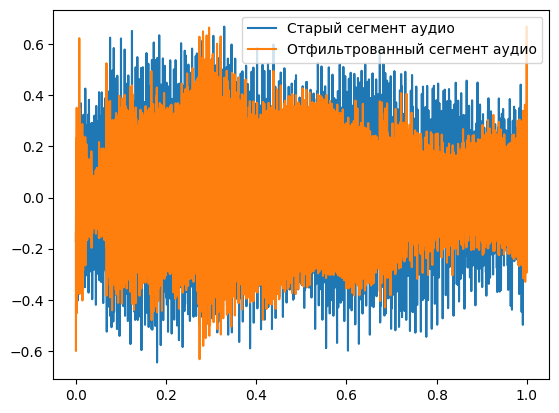

In [77]:
from matplotlib import pyplot
new_wave_segment = spectrum.make_wave()
old_wave_segment = wave.segment(start = 3.3, duration=1)
old_wave_segment.ts -= 3.3

old_wave_segment.plot(label='Старый сегмент аудио')
new_wave_segment.plot(label='Отфильтрованный сегмент аудио')
pyplot.legend()

Многие центральные частоты стали гораздо более выраженными, некоторые выпадающие высокие частоты пропали. В целом сигнал стал намного более "ровным", однородным

In [78]:
new_wave_segment.make_audio()

In [75]:
old_wave_segment.make_audio()


"Выпадающие" высокие частоты делали звук более насыщеннм на звонкие звуки. Глухие мягкие звуки гитары также были обрезаны из-за обрезания низких частот.
Теперь "средние" по яркеости звучания звуки кажутся гораздо громче.

# Упражнение 1.3

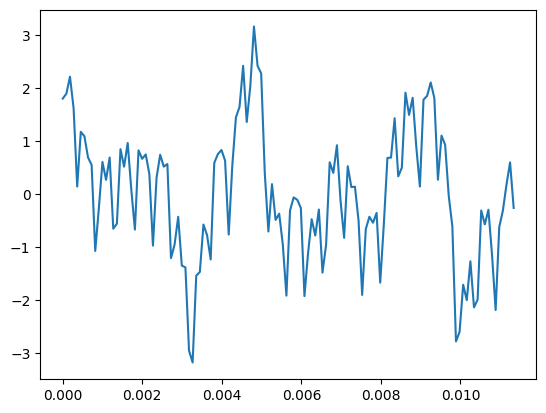

In [124]:
from thinkdsp import CosSignal, SinSignal

cos_sig1 = CosSignal(freq=440, amp=1.0, offset=0)
sin_sig1 = SinSignal(freq=880, amp=0.5, offset=0)
cos_sig2 = CosSignal(freq=1046.5, amp=0.3, offset=0)
sin_sig2 = SinSignal(freq=2093, amp=0.7, offset=0)
cos_sig3 = CosSignal(freq=4186, amp=0.5, offset=0)
sin_sig3 = SinSignal(freq=261.63, amp=1, offset=0)

mix = cos_sig1 + sin_sig1 + cos_sig2 + sin_sig2 + cos_sig3 + sin_sig3
mix.plot()

In [125]:
wave = mix.make_wave()
wave.make_audio()

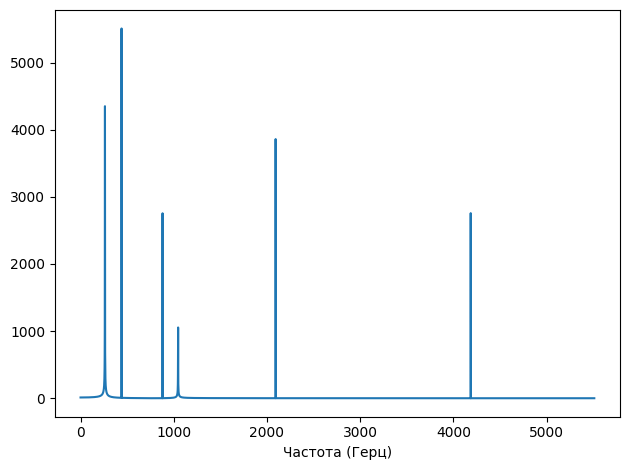

In [126]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Частота (Герц)')

При добавлении частотных компонент, не кратных основным, сигнал будет затухающим

# Упражнение 1.4

In [127]:
def stretch(wave, k):
  wave.ts *= k
  wave.framerate /= k
  return wave

In [128]:
old_wave_segment.make_audio()

In [133]:
slow_old_wave_seg = stretch(old_wave_segment, 4)

In [134]:
slow_old_wave_seg.make_audio()